# On the Role of Fixed Points of Dynamical Systems in Training Physics-Informed Neural Networks

## Introduction
The first part of this paper (2023 - Transaction on Machine Learning Research) present the impact of asymptotically stable, stable and unstable fixed points in two simple dynamical systems described by ODEs:
- An undamped pendulum: $\ddot{y} = \mathcal{F}[y] := - \frac{g}{l} \sin(y)$, where $y$ is the angle of the pendulum with the vertical, and $l=1.0$ and $g=9.81$ are the pendulum length and the graviational constant. No IC is hard-encoded.
- A toy example: $\dot{y} = \mathcal{F}[y] := y(1-y^2)$. Explicit IC is encoded by setting $\hat{y}(t) = y_0 + t y_{\theta}(t)$, where $y_{\theta}(t)$ is the output of the MLP.

In both cases, they evaluate the _learning success_ of PINN's by comparing their predictions with the solutions made using fourth order Runge-Kutta, considering the learning a success if the relative $L^2$ norm between the predicted trajectory and the expected one is below $15\%$. Each solution yielded by a new IC is approximated with a different PINN.

They show that IC close to fixed points and longer simulation times lead to lower success rate. The first is their initial hypothesis.

## Contribution
We first propose, rather than using a different PINN for each solution, to build an unique one that takes $y_0$ and $t$ as input. Then, we further assess the learning success by comparing the phase portrait of the PINN. Finally, we evaluate if the divergence of those systems can be used as an additional constraint for the PINN learning.

In [6]:
%loadlibs
from scipy.integrate import solve_ivp
import pandas as pd
device = 'mps'
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


In [2]:
n_epochs = 5000
n_points = 2000
n_experiments = 10

## Pendulum
We start by generating simulated dataset.

In [3]:
l = 1.0
g = 9.81
T_MAX = 3.0
n_t = 512

def pendule(t, y, g, l):
    theta, theta_dot = y
    dtheta_dt = theta_dot
    dtheta_dot_dt = -(g / l) * np.sin(theta)
    return [dtheta_dt, dtheta_dot_dt]

res = {'y0': [], 't': [], 'y': []}
y_dot0 = 0.0
t_span = (0, T_MAX)
t_eval = np.linspace(*t_span, n_t)
for y0 in np.linspace(-np.pi, np.pi, 361):
    y, y_dot = solve_ivp(pendule, t_span, [y0, y_dot0], args=(g, l), t_eval=t_eval).y
    res['y0'].extend(np.ones(n_t) * y0)
    res['t'].extend(t_eval)
    res['y'].extend(y)
res['y0'] = np.array(res['y0'])
res['t'] = np.array(res['t'])
res['y'] = np.array(res['y'])
df_pendulum = pd.DataFrame(res)

Next, we design the PINN, with two inputs: $y_0, t$.

In [4]:
class PendulumPINN(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.l1 = nn.Linear(2, hidden)
        self.layers = nn.ModuleList([nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh()])
        self.l3 = nn.Linear(hidden, 1)
        
    def forward(self, y0, t):
        inp = torch.cat([y0, t], dim=1)
        h = self.l1(inp)
        for layer in self.layers:
            h = layer(h)
        nn_out = self.l3(h)
        return (nn_out * t**2 + y0)

def loss_fn(model, y0, t):
    t = t.clone().requires_grad_(True)
    theta = model(y0, t)
    theta_t = torch.autograd.grad(theta, t, grad_outputs=torch.ones_like(theta), create_graph=True, retain_graph=True)[0]
    theta_tt = torch.autograd.grad(theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True, retain_graph=True)[0]
    residual = theta_tt + (g / l) * torch.sin(theta)
    physics_loss = torch.mean(residual ** 2)
    return physics_loss

errors_pendulum = np.zeros(len(df_pendulum['y0'].unique()))
models_pendulum = [PendulumPINN() for n in range(n_experiments)]

for n in tqdm(range(n_experiments)):
    model = models_pendulum[n]
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    
    for _ in (pbar := tqdm(range(n_epochs))):
        optimizer.zero_grad()
        t = torch.rand((n_points, 1)) * T_MAX
        y0 = (torch.rand((n_points, 1))-0.5) * 4 * torch.pi
        loss = loss_fn(model, y0, t)
        pbar.set_description(f"Loss:{loss.item():.4e}")
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
    
    for i in range(len(errors_pendulum)):
        y0 = df_pendulum['y0'].unique()[i]
        simulation = df_pendulum[df_pendulum['y0'] == y0]['y'].to_numpy()
        y_hat = model(torch.ones(n_t, 1) * y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().squeeze().detach().numpy()
        errors_pendulum[i] += np.mean((y_hat-simulation)**2)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

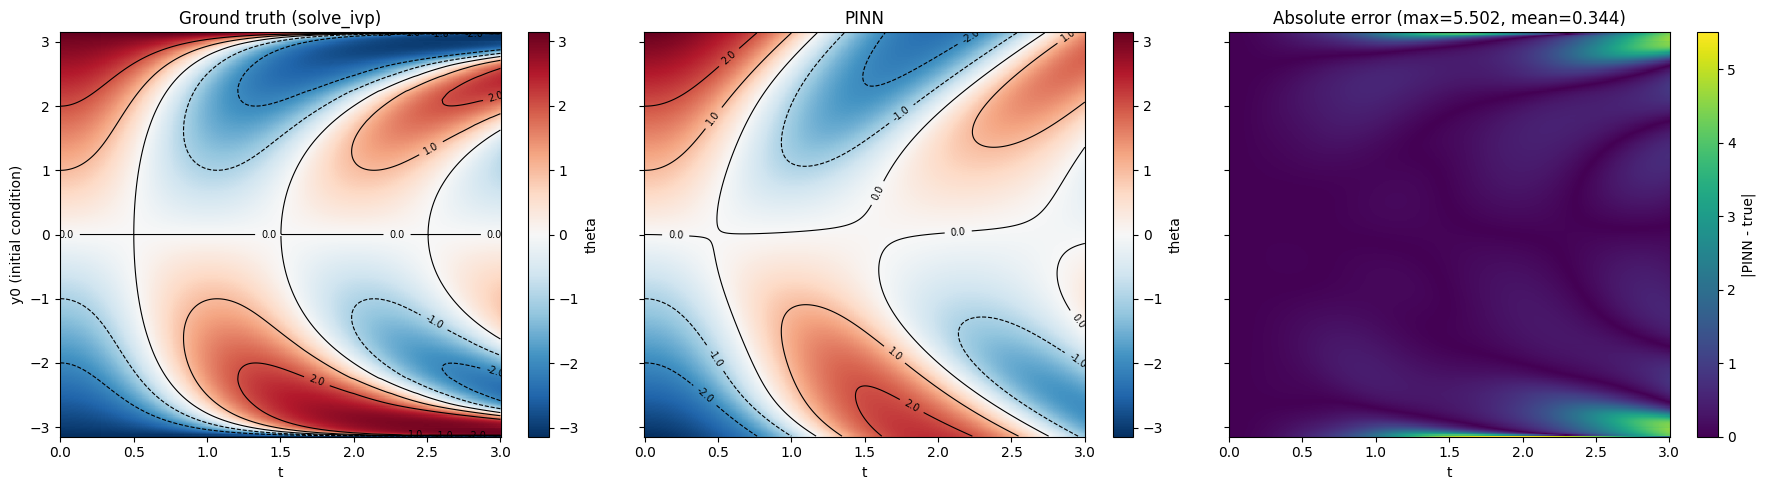

In [7]:
model = models_pendulum[0].eval()
n_t = 512

y0_grid = np.linspace(-np.pi, np.pi, 361)
t_eval = np.linspace(0, T_MAX, n_t)

Y0, T = np.meshgrid(y0_grid, t_eval, indexing="ij")

y0_flat = torch.tensor(Y0.reshape(-1, 1), dtype=torch.float32, device=device)
t_flat  = torch.tensor(T.reshape(-1, 1),  dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred_flat = model(y0_flat, t_flat).cpu().numpy().reshape(-1)

res_pinn = {
    'y0': Y0.reshape(-1),
    't':  T.reshape(-1),
    'y':  y_pred_flat,
}
df_pinn = pd.DataFrame(res_pinn)

grid_true = df_pendulum.pivot(index='y0', columns='t', values='y').values
grid_pred = df_pinn.pivot(index='y0', columns='t', values='y').values

y0_axis = np.sort(df_pendulum['y0'].unique())
t_axis  = np.sort(df_pendulum['t'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

vmin, vmax = -np.pi, np.pi
levels = [-2.0, -1.0, 0.0, 1.0, 2.0]

for ax, grid, title in zip(axes[:2], [grid_true, grid_pred], ["Ground truth (solve_ivp)", "PINN"]):
    pcm = ax.pcolormesh(t_axis, y0_axis, grid, shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
    cs = ax.contour(t_axis, y0_axis, grid, levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cs, fmt="%.1f", fontsize=7)
    ax.set_xlabel("t")
    ax.set_title(title)
    
fig.colorbar(pcm, ax=axes[1], label="theta")
fig.colorbar(pcm, ax=axes[0], label="theta")
axes[0].set_ylabel("y0 (initial condition)")

diff = np.abs(grid_pred - grid_true)
pcm2 = axes[2].pcolormesh(t_axis, y0_axis, diff, shading="auto", cmap="viridis")
fig.colorbar(pcm2, ax=axes[2], label="|PINN - true|")
axes[2].set_xlabel("t")
axes[2].set_title(f"Absolute error (max={diff.max():.3f}, mean={diff.mean():.3f})")

plt.tight_layout()
plt.show()

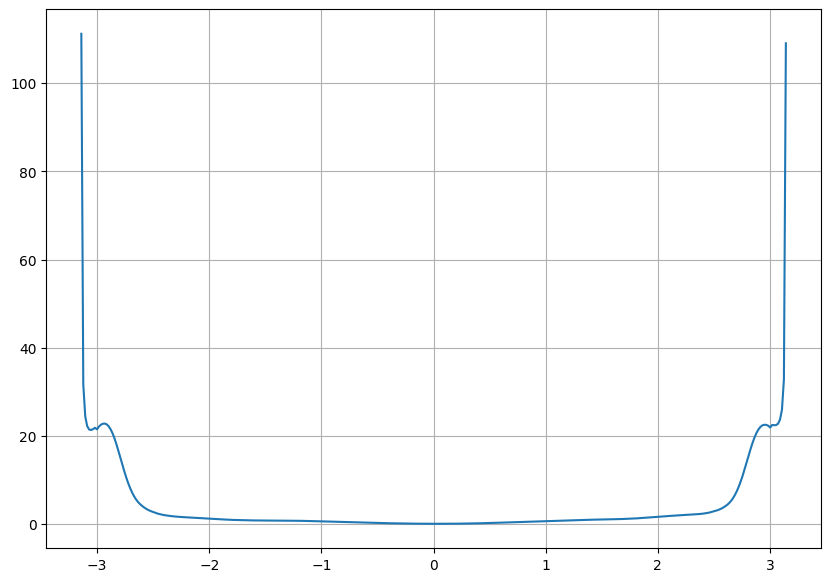

In [8]:
plt.figure(figsize=(10, 7))
plt.plot(df_pendulum['y0'].unique(), errors_pendulum)
plt.grid()
plt.show()

Then, we take a look at the phase portrait.

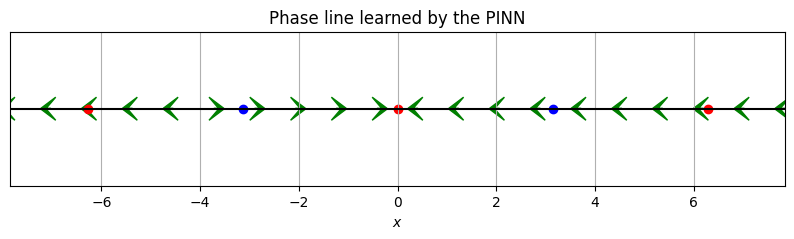

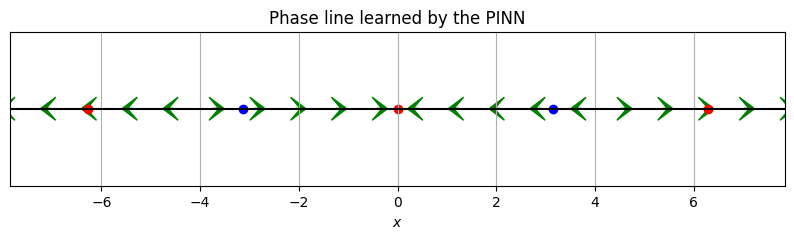

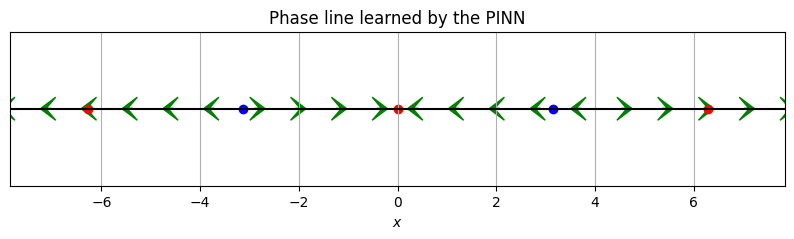

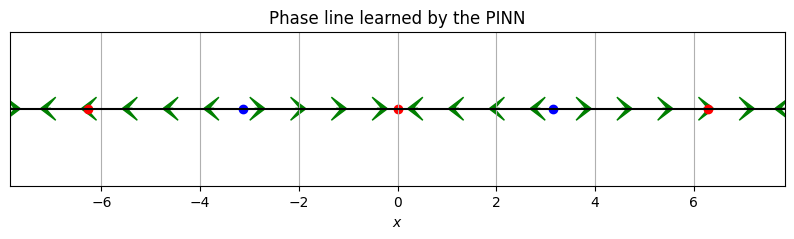

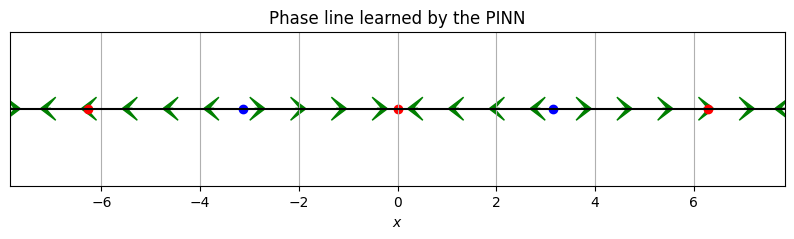

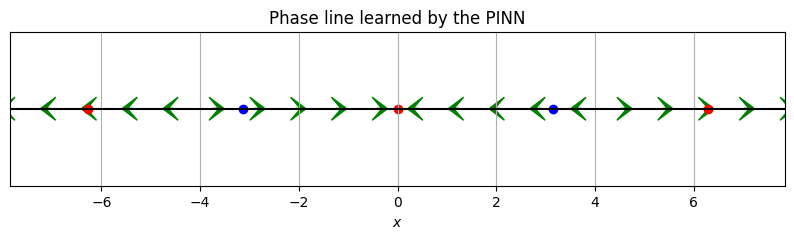

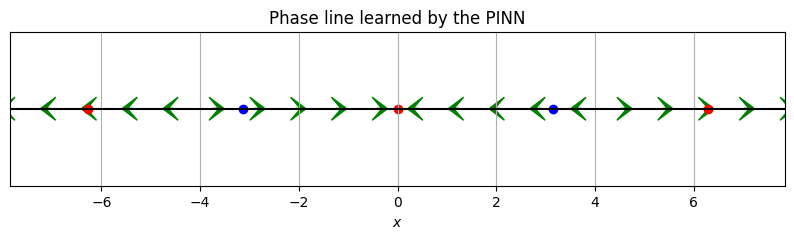

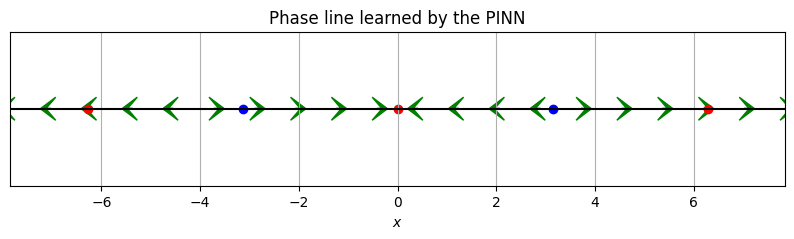

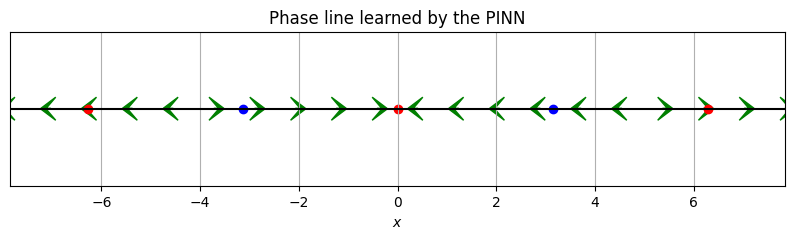

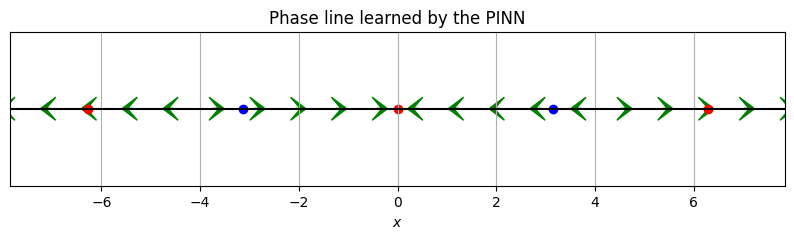

In [9]:
x0 = torch.linspace(-2.5*torch.pi, 2.5*torch.pi, 20).unsqueeze(-1)
t = torch.ones_like(x0, requires_grad=True) * 1e-6
for m in models_pendulum:
    x_pred = m(x0, t)
    
    dxdt = torch.autograd.grad(outputs=x_pred, inputs=t, grad_outputs=torch.ones_like(x_pred))[0]
    
    x_np = x0.cpu().detach().numpy().flatten()
    dxdt_np = dxdt.cpu().detach().numpy().flatten()
    
    plt.figure(figsize=(10, 2))
    plt.hlines(0, -3*torch.pi, 3*torch.pi, color="black")
    
    for xi, fi in zip(x_np, dxdt_np):
        direction = np.sign(fi)
        if direction == 0:
            continue
        plt.arrow(xi, 0, 0.1 * direction, 0, head_width=0.03, head_length=0.2, length_includes_head=True, overhang=1.5, color="green")
    
    plt.scatter([-2*torch.pi, 0, 2*torch.pi], [0, 0, 0], color='red')
    plt.scatter([-torch.pi, torch.pi], [0, 0], color='blue')
    plt.xlim(-2.5*torch.pi, 2.5*torch.pi)
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.xlabel(r"$x$")
    plt.title("Phase line learned by the PINN")
    plt.grid(axis="x")
    
    plt.show()

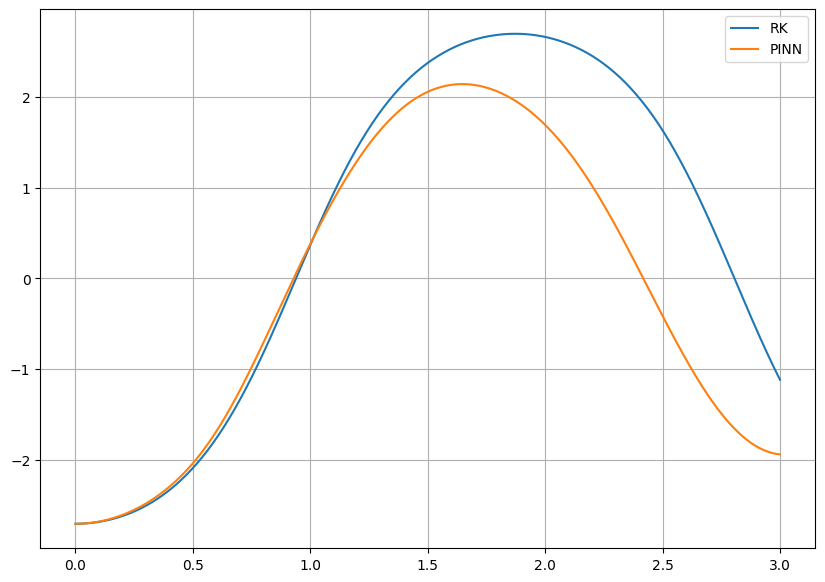

In [10]:
y0_array = df_pendulum['y0'].unique()
simulation = df_pendulum[df_pendulum['y0'] == y0_array[25]]
y_hat = models_pendulum[0](torch.ones_like(torch.tensor(t_eval, dtype=torch.float32)).unsqueeze(-1)*y0_array[25], torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().detach().squeeze()
plt.figure(figsize=(10, 7))
plt.plot(simulation['t'], simulation['y'], label='RK')
plt.plot(simulation['t'], y_hat, label='PINN')
plt.legend()
plt.grid()
plt.show()

We can indeed notice two things:
- The unstable points at $-2\pi$, $2\pi$ are not correct in the phase line.
- The stable points are not always correct.

To be able to compare with the original paper, we check the $\mathcal{L}^2$ norm for each IC.

In [11]:
y0_array = df_pendulum['y0'].unique()
errors_pendulum_ic = []
for y0 in y0_array:
    simulation = df_pendulum[df_pendulum['y0'] == y0]['y'].to_numpy()
    y_hat = models_pendulum[0](torch.ones_like(torch.tensor(t_eval, dtype=torch.float32)).unsqueeze(-1)*y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().detach().squeeze().numpy()
    errors_pendulum_ic.append((np.sum((simulation-y_hat)**2))**0.5 / (1e-6+np.sum((simulation)**2) ** 0.5))
errors_pendulum_ic = np.array(errors_pendulum_ic)
print(f"Success rate: {np.sum(errors_pendulum_ic<0.15)/errors_pendulum_ic.shape[0]}")

Success rate: 0.0


## Toy example
The second system presented is a toy example. We construct the dataset, then the PINN, then the phase portrait.

In [ ]:
T_MAX = 3.0
n_t = 512

def toy(t, y):
    return y * (1 - y**2)

res = {'y0': [], 't': [], 'y': []}
t_span = (0, T_MAX)
t_eval = np.linspace(*t_span, n_t)
for y0 in np.linspace(-2, 2, 256):
    y = solve_ivp(toy, t_span, [y0], t_eval=t_eval).y[0]
    res['y0'].extend(np.ones(n_t) * y0)
    res['t'].extend(t_eval)
    res['y'].extend(y)
res['y0'] = np.array(res['y0'])
res['t'] = np.array(res['t'])
res['y'] = np.array(res['y'])
df_toy = pd.DataFrame(res)

In [ ]:
class ToyPINN(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.l1 = nn.Linear(2, hidden)
        self.layers = nn.ModuleList([nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh()])
        self.l3 = nn.Linear(hidden, 1)
        self.activation = nn.Tanh()
        
    def forward(self, y0, t):
        inp = torch.cat([y0, t], dim=1)
        h = self.l1(inp)
        for layer in self.layers:
            h = layer(h)
        nn_out = self.l3(h)
        return nn_out * t + y0 

def loss_fn(model, y0, t):
    t = t.clone().requires_grad_(True)
    y = model(y0, t)
    y_dt = torch.autograd.grad(y, t, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True)[0]
    residual = y_dt - (y * (1 - y**2))
    physics_loss = torch.mean(residual ** 2)
    return physics_loss
    
errors_toy = np.zeros(len(df_toy['y0'].unique()))
models_toy = [ToyPINN() for n in range(n_experiments)]
for n in tqdm(range(n_experiments)):
    model = models_toy[n]
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    
    for _ in (pbar := tqdm(range(n_epochs))):
        optimizer.zero_grad()
        t = torch.rand((n_points, 1)) * T_MAX
        y0 = (torch.rand((n_points, 1))-0.5) * 4
        loss = loss_fn(model, y0, t)
        pbar.set_description(f"Loss:{loss.item():.4e}")
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
    
    for i in range(len(errors_toy)):
        y0 = df_toy['y0'].unique()[i]
        simulation = df_toy[df_toy['y0'] == y0]['y'].to_numpy()
        y_hat = model(torch.ones(n_t, 1) * y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().squeeze().detach().numpy()
        errors_toy[i] += np.mean((y_hat-simulation)**2)

In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(df_toy['y0'].unique(), errors_toy)
plt.grid()
plt.show()

In [ ]:
x0 = torch.linspace(-2, 2, 15).unsqueeze(-1)
t = torch.ones_like(x0, requires_grad=True) * 1e-6
for m in models_toy:
    x_pred = m(x0, t)
    
    dxdt = torch.autograd.grad(outputs=x_pred, inputs=t, grad_outputs=torch.ones_like(x_pred))[0]
    
    x_np = x0.cpu().detach().numpy().flatten()
    dxdt_np = dxdt.cpu().detach().numpy().flatten()
    
    plt.figure(figsize=(10, 2))
    plt.hlines(0, -2, 2, color="black")
    
    for xi, fi in zip(x_np, dxdt_np):
        direction = np.sign(fi)
        if direction == 0:
            continue
        plt.arrow(xi, 0, 0.1 * direction, 0, head_width=0.03, head_length=0.1, length_includes_head=True, overhang=1.5, color="green")
    
    plt.scatter([0], [0], color='red')
    plt.scatter([-1, 1], [0, 0], color='blue')
    plt.xlim(-2, 2)
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.xlabel(r"$x$")
    plt.title("Phase line learned by the PINN")
    plt.grid(axis="x")
    
    plt.show()

Suprisingly, all the PINN's fail to match the phase portrait.

In [ ]:
y0_array = df_toy['y0'].unique()
simulation = df_toy[df_toy['y0'] == y0_array[25]]
y_hat = models_toy[0](torch.ones_like(torch.tensor(t_eval, dtype=torch.float32)).unsqueeze(-1)*y0_array[25], torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().detach().squeeze()
plt.figure(figsize=(10, 7))
plt.plot(simulation['t'], simulation['y'], label='RK')
plt.plot(simulation['t'], y_hat, label='PINN')
plt.legend()
plt.grid()
plt.show()

In [ ]:
y0_array = df_toy['y0'].unique()
errors_toy_ic = []
for y0 in y0_array:
    simulation = df_toy[df_toy['y0'] == y0]['y'].to_numpy()
    y_hat = models_toy[0](torch.ones_like(torch.tensor(t_eval, dtype=torch.float32)).unsqueeze(-1)*y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().detach().squeeze().numpy()
    errors_toy_ic.append((np.sum((simulation-y_hat)**2))**0.5 / (1e-6+np.sum((simulation)**2) ** 0.5))
errors_toy_ic = np.array(errors_toy_ic)
print(f"Success rate: {np.sum(errors_toy_ic<0.15)/errors_toy_ic.shape[0]}")

## Adding Energy as an Information 
### Pendulum

In [12]:
class PendulumPINN2(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.l1 = nn.Linear(2, hidden)
        self.layers = nn.ModuleList([nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh()])
        self.l3 = nn.Linear(hidden, 1)
        
    def forward(self, y0, t):
        inp = torch.cat([y0, t], dim=1)
        h = self.l1(inp)
        for layer in self.layers:
            h = layer(h)
        nn_out = self.l3(h)
        return (nn_out * t**2 + y0)

def loss_fn2(model, y0, t):
    t = t.clone().requires_grad_(True)
    theta = model(y0, t)
    theta_t = torch.autograd.grad(theta, t, grad_outputs=torch.ones_like(theta), create_graph=True, retain_graph=True)[0]
    theta_tt = torch.autograd.grad(theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True, retain_graph=True)[0]
    residual = theta_tt + (g / l) * torch.sin(theta)
    physics_loss = torch.mean(residual ** 2)

    E = 0.5*theta_t**2 - (g/l)*torch.cos(theta)
    E0 = -(g/l)*torch.cos(y0)
    energy_loss = torch.mean((E - E0)**2)
    return physics_loss + energy_loss

errors_pendulum2 = np.zeros(len(df_pendulum['y0'].unique()))
models_pendulum2 = [PendulumPINN2() for n in range(n_experiments)]

for n in tqdm(range(n_experiments)):
    model = models_pendulum2[n]
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
    
    for _ in (pbar := tqdm(range(n_epochs))):
        optimizer.zero_grad()
        t = torch.rand((n_points, 1)) * T_MAX
        y0 = (torch.rand((n_points, 1))-0.5) * 4 * torch.pi
        loss = loss_fn2(model, y0, t)
        pbar.set_description(f"Loss:{loss.item():.4e}")
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
    
    for i in range(len(errors_pendulum2)):
        y0 = df_pendulum['y0'].unique()[i]
        simulation = df_pendulum[df_pendulum['y0'] == y0]['y'].to_numpy()
        y_hat = model(torch.ones(n_t, 1) * y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().squeeze().detach().numpy()
        errors_pendulum2[i] += np.mean((y_hat-simulation)**2)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

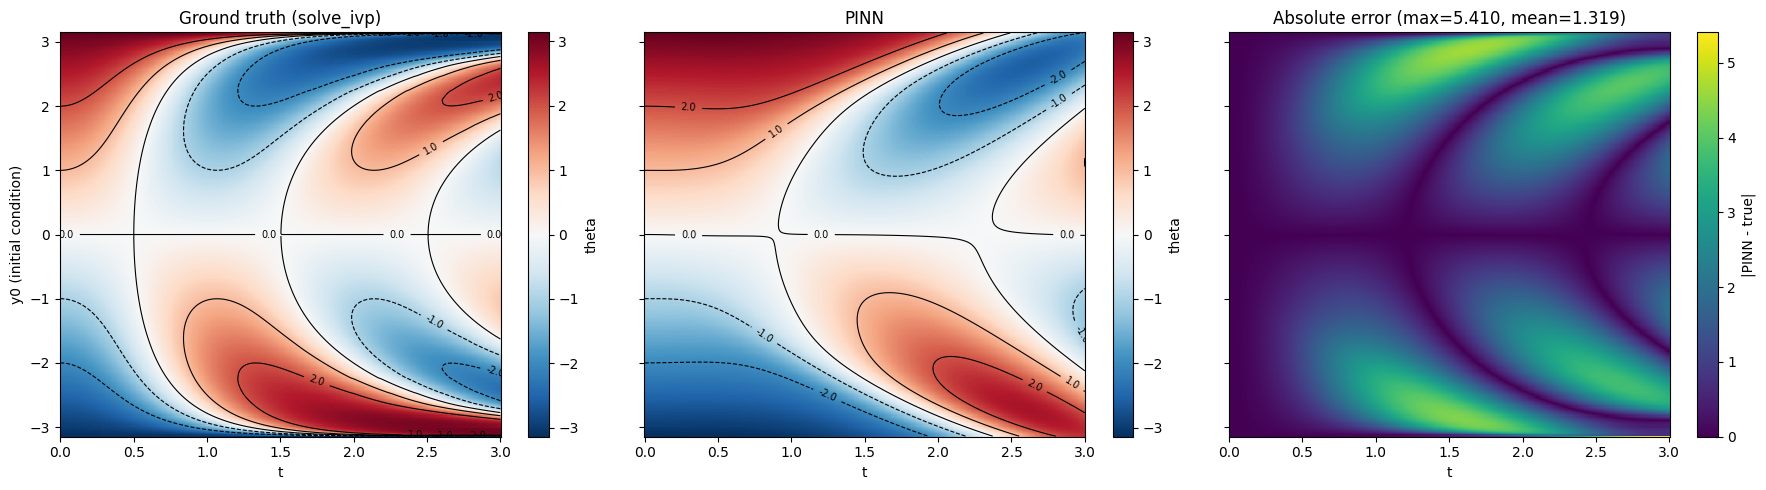

In [13]:
model = models_pendulum2[0].eval()
n_t = 512

y0_grid = np.linspace(-np.pi, np.pi, 361)
t_eval = np.linspace(0, T_MAX, n_t)

Y0, T = np.meshgrid(y0_grid, t_eval, indexing="ij")

y0_flat = torch.tensor(Y0.reshape(-1, 1), dtype=torch.float32, device=device)
t_flat  = torch.tensor(T.reshape(-1, 1),  dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred_flat = model(y0_flat, t_flat).cpu().numpy().reshape(-1)

res_pinn = {
    'y0': Y0.reshape(-1),
    't':  T.reshape(-1),
    'y':  y_pred_flat,
}
df_pinn = pd.DataFrame(res_pinn)

grid_true = df_pendulum.pivot(index='y0', columns='t', values='y').values
grid_pred = df_pinn.pivot(index='y0', columns='t', values='y').values

y0_axis = np.sort(df_pendulum['y0'].unique())
t_axis  = np.sort(df_pendulum['t'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

vmin, vmax = -np.pi, np.pi
levels = [-2.0, -1.0, 0.0, 1.0, 2.0]

for ax, grid, title in zip(axes[:2], [grid_true, grid_pred], ["Ground truth (solve_ivp)", "PINN"]):
    pcm = ax.pcolormesh(t_axis, y0_axis, grid, shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
    cs = ax.contour(t_axis, y0_axis, grid, levels=levels, colors="k", linewidths=0.8)
    ax.clabel(cs, fmt="%.1f", fontsize=7)
    ax.set_xlabel("t")
    ax.set_title(title)
    
fig.colorbar(pcm, ax=axes[1], label="theta")
fig.colorbar(pcm, ax=axes[0], label="theta")
axes[0].set_ylabel("y0 (initial condition)")

diff = np.abs(grid_pred - grid_true)
pcm2 = axes[2].pcolormesh(t_axis, y0_axis, diff, shading="auto", cmap="viridis")
fig.colorbar(pcm2, ax=axes[2], label="|PINN - true|")
axes[2].set_xlabel("t")
axes[2].set_title(f"Absolute error (max={diff.max():.3f}, mean={diff.mean():.3f})")

plt.tight_layout()
plt.show()

In [14]:
y0_array = df_pendulum['y0'].unique()
errors_pendulum_ic = []
for y0 in y0_array:
    simulation = df_pendulum[df_pendulum['y0'] == y0]['y'].to_numpy()
    y_hat = models_pendulum2[0](torch.ones_like(torch.tensor(t_eval, dtype=torch.float32)).unsqueeze(-1)*y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().detach().squeeze().numpy()
    errors_pendulum_ic.append((np.sum((simulation-y_hat)**2))**0.5 / (1e-6+np.sum((simulation)**2) ** 0.5))
errors_pendulum_ic = np.array(errors_pendulum_ic)
print(f"Success rate: {np.sum(errors_pendulum_ic<0.15)/errors_pendulum_ic.shape[0]}")

Success rate: 0.0
